# Telecom X – Análise de Evasão de Clientes - P2

### Bibliotecas

In [53]:
# Importa as Bibliotecas
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay


### Extração dos Dados


In [3]:
# Dados disponibilizados já tratados
df = pd.read_csv("dados_tratados.csv")
df.head(1)


,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.3


### Funções e Variáveis Auxiliares

In [4]:
# Colunas Categóricas - Exceto customerID 
colunas_categoricas = ['Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod']

In [5]:
def valores_categoricas(df, colunas_categoricas):
    valores_unicos_categoricas = pd.DataFrame({
        "Coluna": colunas_categoricas,
        "Qtde categorias": [df[col].nunique() for col in colunas_categoricas],
        "Valores únicos": [
            ", ".join(sorted(df[col].astype(str).unique()))
            for col in colunas_categoricas
        ],
        "Frequências": [
            " | ".join(
                f"{k} ({v})" for k, v in df[col].value_counts().items()
            )
            for col in colunas_categoricas
        ]
    })

    return valores_unicos_categoricas

In [44]:


def avaliar_modelo(nome, y_test, pred):

    print(f"Modelo: {nome}")
    print("Acurácia:", accuracy_score(y_test, pred))
    
    print("\nRelatório de Classificação:")
    print(classification_report(y_test, pred))
    
    ConfusionMatrixDisplay.from_predictions(y_test, pred,  cmap="Blues")
    
    plt.title(f"Matriz de Confusão - {nome}")
    plt.show()

### Conhecendo o Dataset

#### Dicionário de dados

* `customerID`: número de identificação único de cada cliente
* `Churn`: se o cliente deixou ou não a empresa 
* `gender`: gênero (masculino e feminino) 
* `SeniorCitizen`: informação sobre um cliente ter ou não idade igual ou maior que 65 anos 
* `Partner`:  se o cliente possui ou não um parceiro ou parceira
* `Dependents`: se o cliente possui ou não dependentes
* `tenure`:  meses de contrato do cliente
* `PhoneService`: assinatura de serviço telefônico 
* `MultipleLines`: assisnatura de mais de uma linha de telefone 
* `InternetService`: assinatura de um provedor internet 
* `OnlineSecurity`: assinatura adicional de segurança online 
* `OnlineBackup`: assinatura adicional de backup online 
* `DeviceProtection`: assinatura adicional de proteção no dispositivo 
* `TechSupport`: assinatura adicional de suporte técnico, menos tempo de espera
* `StreamingTV`: assinatura de TV a cabo 
* `StreamingMovies`: assinatura de streaming de filmes 
* `Contract`: tipo de contrato
* `PaperlessBilling`: se o cliente prefere receber online a fatura
* `PaymentMethod`: forma de pagamento
* `Charges.Monthly`: total de todos os serviços do cliente por mês
* `Charges.Total`: total gasto pelo cliente

#### Conhecendo Dados e Estruturas

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


In [7]:
# Verificando os valores categóricos
valores_categoricas(df, colunas_categoricas)

,Coluna,Qtde categorias,Valores únicos,Frequências
0,Churn,2,"No, Yes",No (5174) | Yes (1869)
1,Gender,2,"Female, Male",Male (3555) | Female (3488)
2,SeniorCitizen,2,"No, Yes",No (5901) | Yes (1142)
3,Partner,2,"No, Yes",No (3641) | Yes (3402)
4,Dependents,2,"No, Yes",No (4933) | Yes (2110)
5,PhoneService,2,"No, Yes",Yes (6361) | No (682)
6,MultipleLines,2,"No, Yes",No (4072) | Yes (2971)
7,InternetService,3,"DSL, Fiber optic, No",Fiber optic (3096) | DSL (2421) | No (1526)
8,OnlineSecurity,2,"No, Yes",No (5024) | Yes (2019)
9,OnlineBackup,2,"No, Yes",No (4614) | Yes (2429)


### Preparação dos Dados

#### Remoção de Colunas Irrelevantes

In [8]:
# Removendo colunas desnecessárias
df = df.drop(columns=['CustomerID'])
df.head(1)

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.3


#### Encoding

In [9]:
# Aplicando one-hot encoding.
df_model = pd.get_dummies(df, drop_first=True)

In [ ]:
# Separar variáveis
X = df_model.drop("Churn_Yes", axis=1)
y = df_model["Churn_Yes"]

#### Verificação da Proporção de Evasão

In [ ]:
# Proporção da Evasão em Quantidade
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [ ]:
# Proporção da Evasão em Porcentagem
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

#### Normalização

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### Análise de Correlação

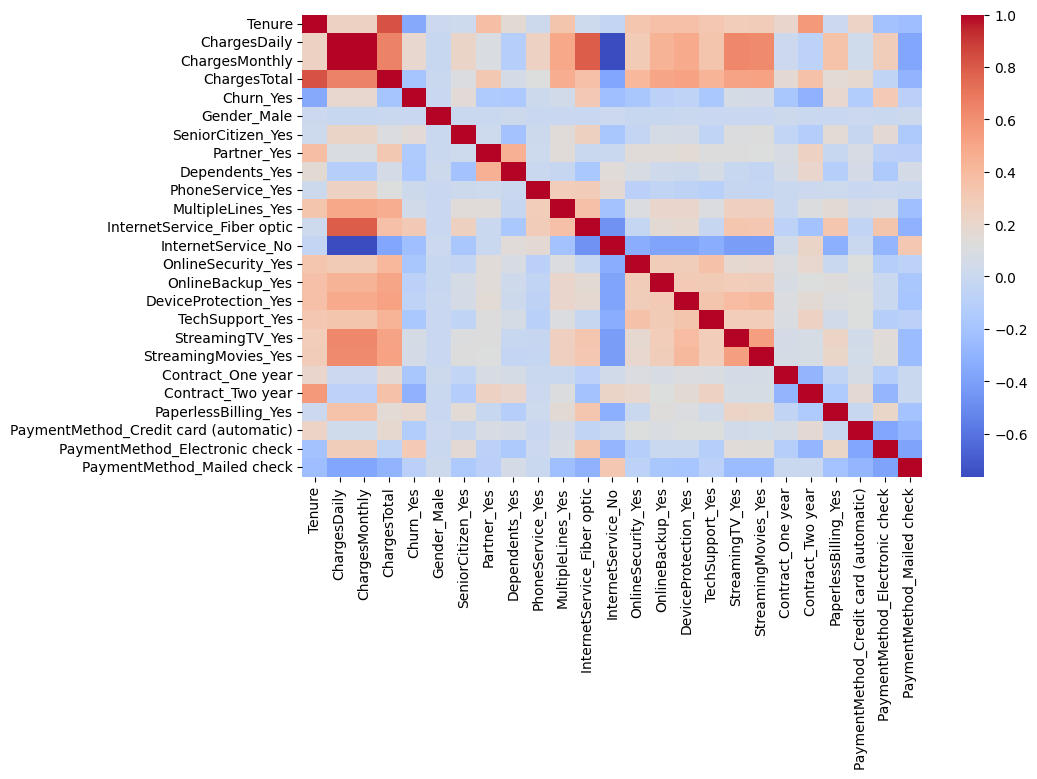

In [48]:
# Matriz de Correlação 
plt.figure(figsize=(10,6))
sns.heatmap(df_model.corr(), cmap="coolwarm")
plt.show()

In [16]:
# Correlação com churn:
df_model.corr()["Churn_Yes"].sort_values(ascending=False)

Churn_Yes                                1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
ChargesDaily                             0.193412
ChargesMonthly                           0.193356
PaperlessBilling_Yes                     0.191825
SeniorCitizen_Yes                        0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService_Yes                         0.011942
Gender_Male                             -0.008612
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner_Yes                             -0.150448
Dependents_Yes                          -0.164221
TechSupport_Yes                         -0.164674
OnlineSecurity_Yes                      -0.171226


#### Análises Direcionadas

<Axes: xlabel='Churn', ylabel='Tenure'>

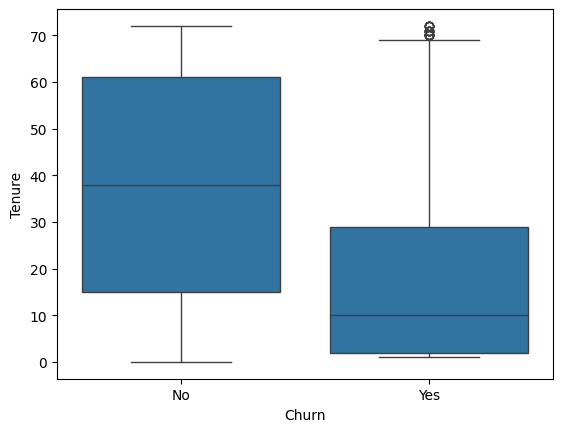

In [17]:
# Tenure × Churn
sns.boxplot(x="Churn", y="Tenure", data=df)

<Axes: xlabel='Churn', ylabel='ChargesTotal'>

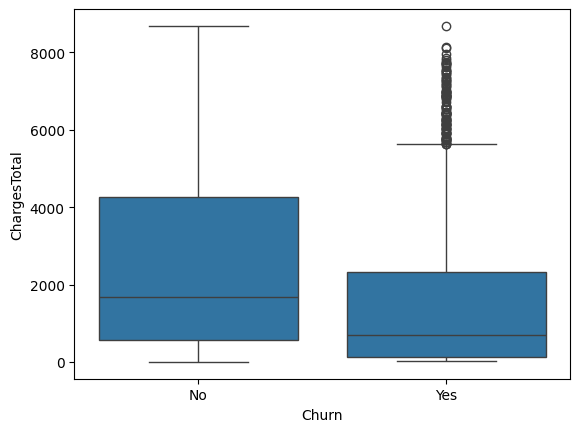

In [19]:
# ChargesTotal × Churn
sns.boxplot(x="Churn", y="ChargesTotal", data=df)

### Modelagem Preditiva

#### Separação de Dados

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

#### Criação de Modelos

In [22]:
# Modelo Regressão Logistica
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train, y_train)

pred_lr = model_lr.predict(X_test)

In [24]:
# Modelo Random Forest
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=42)

model_rf.fit(X_train, y_train)

pred_rf = model_rf.predict(X_test)


#### Avaliação dos Modelos

Modelo: Logistic Regression
Acurácia: 0.8062455642299503

Relatório de Classificação:
              precision    recall  f1-score   support

       False       0.84      0.90      0.87      1036
        True       0.67      0.54      0.59       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



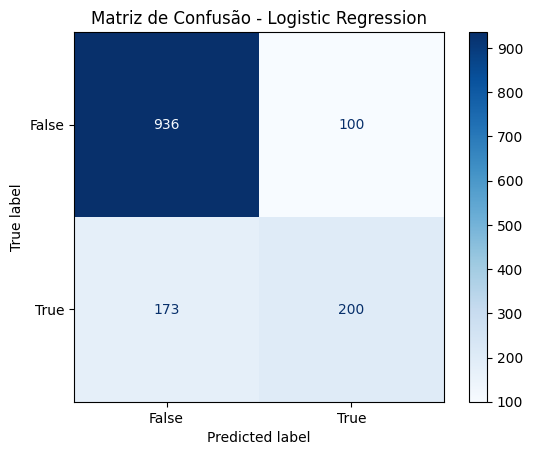

In [45]:
# Avaliação Regressão Logistica
avaliar_modelo("Logistic Regression", y_test, pred_lr)

Modelo: Random Forest
Acurácia: 0.794180269694819

Relatório de Classificação:
              precision    recall  f1-score   support

       False       0.82      0.91      0.87      1036
        True       0.66      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



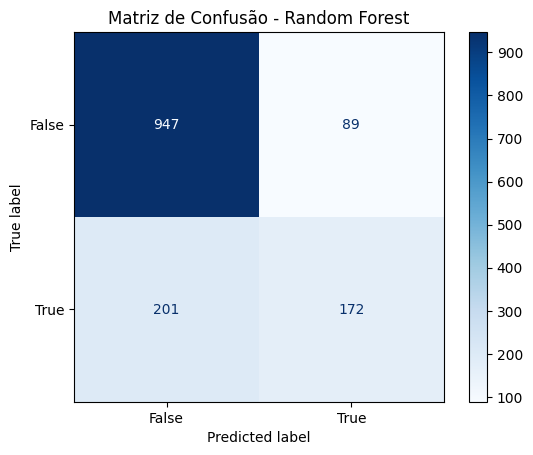

In [47]:
# Avaliação Arvore de Decisão
avaliar_modelo("Random Forest", y_test, pred_rf)

### Interpretação e Conclusões

#### Análise de Importância das Variáveis

In [34]:
# Coeficientes Regressão Logistica
coef = pd.Series(model_lr.coef_[0], index=X.columns)
coef.sort_values(ascending=False).head(10)

ChargesTotal                      0.685045
InternetService_Fiber optic       0.552369
StreamingTV_Yes                   0.178881
MultipleLines_Yes                 0.174360
PaymentMethod_Electronic check    0.165460
StreamingMovies_Yes               0.147846
PaperlessBilling_Yes              0.145425
SeniorCitizen_Yes                 0.067949
DeviceProtection_Yes              0.025285
Partner_Yes                      -0.004280
dtype: float64

In [ ]:
# Arvore de Decisão 
importances = pd.Series(
    model_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.head(10)

ChargesTotal                      0.166585
Tenure                            0.157050
ChargesMonthly                    0.142457
ChargesDaily                      0.120476
Contract_Two year                 0.039393
PaymentMethod_Electronic check    0.037389
InternetService_Fiber optic       0.037207
PaperlessBilling_Yes              0.024724
Gender_Male                       0.024536
Contract_One year                 0.023783
dtype: float64

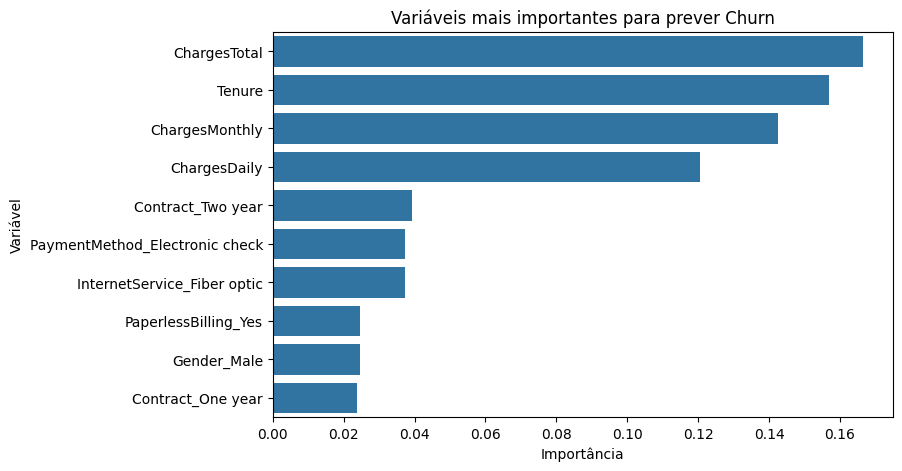

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x=importances.head(10), y=importances.head(10).index)

plt.title("Variáveis mais importantes para prever Churn")
plt.xlabel("Importância")
plt.ylabel("Variável")

plt.show()

# Relatório Previsão de Evasão de Clientes (Churn)

## 1. Visão Geral 

Este projeto teve como objetivo desenvolver modelos de Machine Learning capazes de prever quais clientes possuem maior probabilidade de cancelar os serviços da empresa (churn). A previsão antecipada da evasão permite que a empresa desenvolva estratégias de retenção direcionadas, reduzindo perdas de receita e aumentando a fidelização dos clientes.

A base de dados utilizada contém 7043 clientes, sendo:

- Clientes ativos: 5174 (73,46%)
- Clientes churn: 1869 (26,53%)

---

## 2. Modelagem Preditiva

Foram treinados dois modelos: Regressão Logística e Random Forest.

- Melhor desempenho: Regressão Logística  
  - Acurácia: 0.81  
  - F1-score para churn: 0.59

---

## 3. Clientes e Variáveis que Mais Influenciam o Churn

Clientes com maior risco de evasão geralmente apresentam:

- Baixo tempo de relacionamento (Tenure)  
- Contratos mensais  
- Internet Fiber Optic  
- Pagamento via Electronic Check  
- Gastos mensais ou totais altos

Esses fatores financeiros, contratuais e de tempo de vínculo são os principais drivers de churn e indicam quais clientes merecem atenção prioritária da empresa.

---

## 4. Perfil que a Empresa Deve Manter Próximo

- Clientes com maior tenure  
- Contratos de 1 ou 2 anos  
- Uso ativo de serviços adicionais (suporte técnico, segurança online)  
- Pagamento automático ou métodos com menor atrito

Foco em fidelização desses clientes maximiza retenção e receita.

---

## 5. Conclusão 

O estudo indica que a Regressão Logística é o modelo mais adequado para identificar clientes com risco de churn.

Os esforços de retenção devem priorizar clientes recentes, com contratos mensais e altos gastos, enquanto mantém próximos os clientes com tempo de relacionamento mais longo e contratos de longo prazo.

